In [99]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandasql as pdsql
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.metrics import root_mean_squared_error

import random
np.random.seed(42)
random.seed(42)

In [ ]:
# Path to my data 
data_path = "project/microsoft_corp/data_clean.csv"

# Reading the data 
data = pd.read_csv(data_path, parse_dates=['date'])

# Adjust the index 
data = data.set_index('date')

# Display cleaned time series dataset
display(data.head())

,volume,adjprice,oil,gold,sp500,vix,rates_10y
date,,,,,,,
2010-01-04,38409100.0,23.077383,81.510002,1117.699951,1132.989990,20.040001,3.841
2010-01-05,49749600.0,23.084843,81.769997,1118.099976,1136.520020,19.350000,3.755
2010-01-06,58182400.0,22.943165,83.180000,1135.900024,1137.140015,19.160000,3.808
2010-01-07,50559700.0,22.704561,82.660004,1133.099976,1141.689941,19.059999,3.822
2010-01-08,51197400.0,22.861149,82.750000,1138.199951,1144.979980,18.129999,3.808


In [101]:
def create_dataset(series, window_size, lead_time):
    X, y = [], []

    # Ensure data is in numpy format for easier indexing
    if isinstance(series, pd.Series) or isinstance(series, pd.DataFrame):
        data = series.values
    else:
        data = series

    # We loop through the data, stopping before we run out of future values to predict
    for i in range(len(data) - window_size - lead_time + 1):
        # Input: sequence from i to i + window_size
        X.append(data[i : i + window_size])

        # Output: the value at lead_time steps after the window ends
        y.append(data[i + window_size + lead_time - 1])

    return np.array(X), np.array(y)

In [102]:
# Create the dataset using the parameters and the function defined 
target_col = 'adjprice'
window_size = 7
lead_time = 1

X, y = create_dataset(data[target_col], window_size=window_size, lead_time=lead_time)

print("Dataset Construction Complete.")
print(f"Shape of X: {X.shape}  -> (n_samples, window_size)")
print(f"Shape of y: {y.shape}      -> (n_samples,)")

Dataset Construction Complete.
Shape of X: (4017, 7)  -> (n_samples, window_size)
Shape of y: (4017,)      -> (n_samples,)


In [103]:
# As before, we take until 2019 for training, until 2022 for validation and then until 2026 for test
y_dates = data.index[window_size + lead_time - 1:]
train_end_idx = np.where(y_dates.year <= 2019)[0][-1] + 1
val_end_idx = np.where(y_dates.year <= 2022)[0][-1] + 1

X_train, y_train = X[:train_end_idx], y[:train_end_idx]
X_val, y_val = X[train_end_idx:val_end_idx], y[train_end_idx:val_end_idx]
X_test, y_test = X[val_end_idx:], y[val_end_idx:]

print(f"Train: {y_dates[0].date()} -> {y_dates[train_end_idx-1].date()}  ({len(X_train)}) ({round(len(X_train)/len(data)*100)}%)")
print(f"Val:   {y_dates[train_end_idx].date()} -> {y_dates[val_end_idx-1].date()}  ({len(X_val)}) ({round(len(X_val)/len(data)*100)}%)")
print(f"Test:  {y_dates[val_end_idx].date()} -> {y_dates[-1].date()}  ({len(X_test)}) ({round(len(X_test)/len(data)*100)}%)")

Train: 2010-01-13 -> 2019-12-31  (2509) (62%)
Val:   2020-01-02 -> 2022-12-30  (756) (19%)
Test:  2023-01-03 -> 2025-12-31  (752) (19%)


## Persistence Model 

$$\hat{y}_{t+1} = y_t$$


In [104]:
# The last element of the sequences of values in X test is y

# Extract the last observed value from each window in the test set
y_pred_persistence = X_test[:, -1] # every row and last column 

print(f"Number of predictions: {len(y_pred_persistence)}")
print(f"First 5 predictions: {y_pred_persistence[:5]}")
print(f"First 5 actual values: {y_test[:5]}")

Number of predictions: 752
First 5 predictions: [233.68666077 233.45281982 223.24081421 216.6244812  219.17747498]
First 5 actual values: [233.45281982 223.24081421 216.6244812  219.17747498 221.31147766]


In [105]:
# Calculate Mean Squared Error
mse_persistence = mean_squared_error(y_test, y_pred_persistence)
mae_persistence = mean_absolute_error(y_test, y_pred_persistence)
mape_persistence = mean_absolute_percentage_error(y_test, y_pred_persistence)
rmse_persistance = root_mean_squared_error(y_test, y_pred_persistence)

print(f"Persistence Model MSE: {mse_persistence:.4f}")
print(f"Persistence Model MAE: {mae_persistence:.4f}")
print(f"Persistence Model MAPE: {mape_persistence:.4f}")
print(f"Persistence Model RMSE: {rmse_persistance:.4f}")

Persistence Model MSE: 30.5253
Persistence Model MAE: 4.0119
Persistence Model MAPE: 0.0105
Persistence Model RMSE: 5.5250


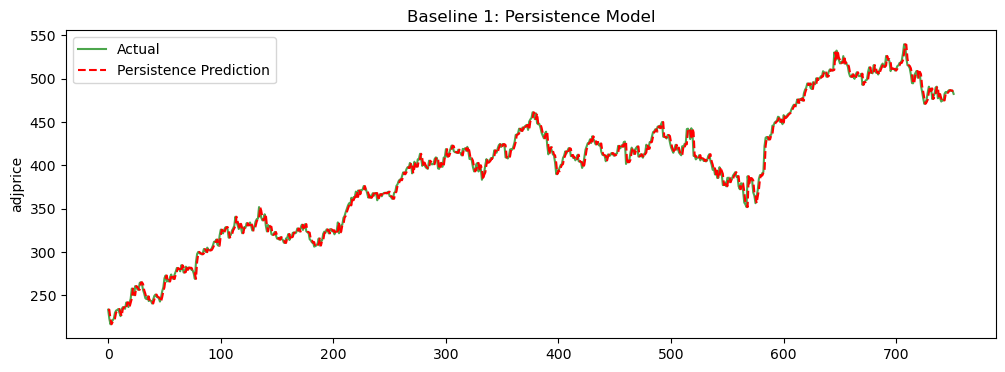

In [106]:
# Visualization 
plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Actual', color='green', alpha=0.7)
plt.plot(y_pred_persistence, label='Persistence Prediction', color='red', linestyle='--')

plt.title("Baseline 1: Persistence Model")
plt.ylabel("adjprice")
plt.legend()
plt.show()